# Sudoku hard-only study

Companion to `sudoku_qualitative_study.ipynb` that focuses on the hard tail of
the timvink-rated `sapientinc-sudoku-extreme` test split. The original
parquet is dominated by BruteForce-tier puzzles (1714 / 2000) and has 0
Advanced / Master coverage, so it can't tell us where (if anywhere) the
BPTT-vs-StopGrad gap actually opens up.

This notebook either:

1. **Loads `sudoku_analysis_hard.parquet`** (produced by
   `submit_sudoku_qualitative_dumps.sh HARD_FILTER=hard ...`) — the dataloader
   has been pre-filtered to top-decile puzzles (rating >= 50, num_steps >= 8,
   or any Advanced/Master strategy). Every row is a hard puzzle.
2. **Or falls back to filtering the existing `sudoku_analysis.parquet`** in-
   memory by the same predicate, so you can preview the hard-only story
   before re-dumping. With ~2000 puzzles the hard subset is tiny but already
   non-empty thanks to the corrected tier mapping.

Sections:

1. Bootstrap & load
2. Hard-cohort definition (rating-based + tier-based)
3. F1' — Pareto on hard puzzles only
4. F2' — paired Δ BPTT − StopGrad (per-puzzle, per-seed) with bootstrap CIs
5. F4' — legality + late-step purity on hard puzzles only
6. F3' — solver alignment on hard puzzles only (paired)
7. Coverage-gated matched-NFE
8. Per-stratum table (Easy / Medium / Advanced / Master / BF-rating-tail)


In [1]:
import sys
from pathlib import Path

def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'doublebackprop' / 'sudoku_analysis.py').is_file():
            return p
    raise RuntimeError('Run from inside the double-backprop repo')

_root = _repo_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from doublebackprop import sudoku_analysis as sa

PARQUET_HARD = _root / 'outputs' / 'sudoku_analysis_hard' / 'sudoku_analysis_hard.parquet'
PARQUET_FULL = _root / 'outputs' / 'sudoku_analysis' / 'sudoku_analysis.parquet'
FIGS = _root / 'outputs' / 'sudoku_analysis_hard' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)
print('parquet (hard):', PARQUET_HARD, PARQUET_HARD.exists())
print('parquet (full):', PARQUET_FULL, PARQUET_FULL.exists())
print('figs:          ', FIGS)

parquet (hard): /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_hard/sudoku_analysis_hard.parquet True
parquet (full): /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis/sudoku_analysis.parquet True
figs:           /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_hard/figures


In [2]:
OBJECTIVE_ORDER = [
    'mlm_uniform',
    'puma_no_loopholing',
    'puma_loopholing_stop_grad',
    'puma_loopholing_bptt',
]
OBJECTIVE_LABEL = {
    'mlm_uniform': 'Uniform MLM',
    'puma_no_loopholing': 'No-Relay (PUMA only)',
    'puma_loopholing_stop_grad': 'Relay (StopGrad)',
    'puma_loopholing_bptt': 'LEAR (BPTT)',
}
OBJECTIVE_COLOR = {
    'mlm_uniform': '#888888',
    'puma_no_loopholing': '#1f77b4',
    'puma_loopholing_stop_grad': '#ff7f0e',
    'puma_loopholing_bptt': '#d62728',
}
STRATEGY_ORDER = ['Easy', 'Medium', 'Advanced', 'Master', 'BruteForce']

def _load_one(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if 'seed' not in df.columns:
        df['seed'] = pd.NA
    df['seed'] = df['seed'].astype('Int64')
    df['hardest_strategy'] = pd.Categorical(
        df['hardest_strategy'], categories=STRATEGY_ORDER, ordered=True
    )
    df['objective'] = pd.Categorical(
        df['objective'], categories=OBJECTIVE_ORDER, ordered=True
    )
    return df

if PARQUET_HARD.exists():
    df_raw = _load_one(PARQUET_HARD)
    SOURCE = 'hard-dump'
elif PARQUET_FULL.exists():
    df_raw = _load_one(PARQUET_FULL)
    SOURCE = 'full-dump (filtered in-memory)'
else:
    raise FileNotFoundError('No parquet found; re-run dump first.')
print('loaded source:', SOURCE)
print('rows:', len(df_raw),
      '| unique runs:', df_raw['run_id'].nunique(),
      '| unique tau:', sorted(df_raw['tau'].unique()),
      '| unique seeds:', sorted([int(s) for s in df_raw['seed'].dropna().unique().tolist()]),
      '| unique puzzles:', df_raw['puzzle_hash'].nunique())
df_raw['hardest_strategy'].value_counts(dropna=False).reindex(STRATEGY_ORDER, fill_value=0)

loaded source: hard-dump
rows: 308000 | unique runs: 22 | unique tau: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.25), np.float64(0.35), np.float64(0.45)] | unique seeds: [1, 2, 3] | unique puzzles: 2000


hardest_strategy
Easy            7546
Medium         13706
Advanced       16478
Master           924
BruteForce    269346
Name: count, dtype: int64

## Hard-cohort definition

Three orthogonal hard-cohort knobs; combine with OR. Default mirrors
`sudoku_extreme_hard_filter_fn`.

- `RATING_MIN`: keep puzzles whose timvink rating is in the top ~10% of the
  test split (p90 ≈ 51 in the full split).
- `NUM_STEPS_MIN`: keep puzzles whose solver took 8+ steps (p90 of the split).
- `KEEP_TIERS`: keep puzzles whose hardest-tier label is in this set; with the
  corrected `STRATEGY_TIERS` mapping (plural-aware) Advanced/Master finally
  populate.

Drop the diverged-seed tuples first (in case the dump pipeline didn't already).

In [3]:
RATING_MIN = 50
NUM_STEPS_MIN = 8
KEEP_TIERS = {'Advanced', 'Master'}
DIVERGED_SEED_TUPLES = [
    ('mlm_uniform', 'tied', 3),
    ('puma_loopholing_stop_grad', 'tied', 1),
]

df = df_raw.copy()
for obj, ty, sd in DIVERGED_SEED_TUPLES:
    mask = (
        (df['objective'] == obj)
        & (df['embed_tying'] == ty)
        & (df['seed'] == sd)
    )
    df = df[~mask].copy()

if SOURCE == 'hard-dump':
    df_hard = df  # already filtered server-side
else:
    rating_ok = df['rating'].fillna(-1) >= RATING_MIN
    steps_ok = df['num_steps_solver'].fillna(-1) >= NUM_STEPS_MIN
    tier_ok = df['hardest_strategy'].astype(str).isin(KEEP_TIERS)
    keep_hashes = df.loc[rating_ok | steps_ok | tier_ok, 'puzzle_hash'].unique()
    df_hard = df[df['puzzle_hash'].isin(keep_hashes)].copy()

n_puzzles_hard = df_hard['puzzle_hash'].nunique()
n_puzzles_full = df_raw['puzzle_hash'].nunique()
COHORT_LABEL = (
    f'hard cohort: {n_puzzles_hard}/{n_puzzles_full} puzzles | '
    f'(rating>={RATING_MIN}) | (num_steps_solver>={NUM_STEPS_MIN}) | '
    f'tier in {sorted(KEEP_TIERS)} | source={SOURCE}'
)
print(COHORT_LABEL)
print('\nper-tier puzzle counts (hard):')
print(df_hard.drop_duplicates('puzzle_hash')['hardest_strategy']
      .value_counts().reindex(STRATEGY_ORDER, fill_value=0))
print('\nrating quantiles (hard):')
print(df_hard.drop_duplicates('puzzle_hash')['rating']
      .quantile([0.5, 0.75, 0.9, 0.99, 1.0]).round(1).to_dict())
print('\nrun count per (objective, embed_tying):')
print(df_hard.drop_duplicates('run_id')
      .groupby(['objective', 'embed_tying'], observed=True)
      .size())

hard cohort: 2000/2000 puzzles | (rating>=50) | (num_steps_solver>=8) | tier in ['Advanced', 'Master'] | source=hard-dump

per-tier puzzle counts (hard):
hardest_strategy
Easy            49
Medium          89
Advanced       107
Master           6
BruteForce    1749
Name: count, dtype: int64

rating quantiles (hard):
{0.5: 13.0, 0.75: 57.0, 0.9: 74.0, 0.99: 131.0, 1.0: 219.0}

run count per (objective, embed_tying):
objective                  embed_tying
mlm_uniform                tied           2
                           untied         3
puma_no_loopholing         tied           3
                           untied         3
puma_loopholing_stop_grad  tied           2
                           untied         3
puma_loopholing_bptt       tied           3
                           untied         3
dtype: int64


## F1' — Pareto on hard puzzles only

Same axes as F1 in the full notebook; titles include n_hard so we can see how
many puzzles each cell averages over.

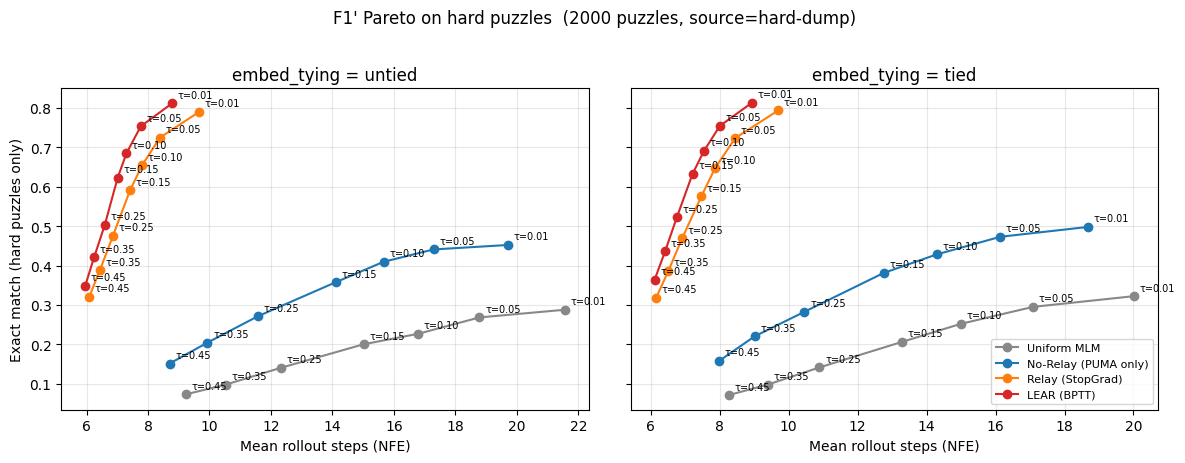

,objective,embed_tying,tau,exact_match,rollout_steps,n
0,mlm_uniform,tied,0.01,0.322500,20.023500,4000
1,mlm_uniform,tied,0.05,0.295250,17.088250,4000
2,mlm_uniform,tied,0.10,0.252250,14.995250,4000
3,mlm_uniform,tied,0.15,0.206250,13.280000,4000
4,mlm_uniform,tied,0.25,0.141750,10.894500,4000
5,mlm_uniform,tied,0.35,0.098250,9.397000,4000
6,mlm_uniform,tied,0.45,0.071500,8.260500,4000
7,mlm_uniform,untied,0.01,0.288000,21.567500,6000
8,mlm_uniform,untied,0.05,0.268500,18.784167,6000
9,mlm_uniform,untied,0.10,0.227000,16.791000,6000


In [4]:
agg = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)
    .agg(exact_match=('exact_match', 'mean'),
         rollout_steps=('rollout_steps', 'mean'),
         n=('exact_match', 'size'))
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, tying in zip(axes, ['untied', 'tied']):
    sub = agg[agg['embed_tying'] == tying]
    for obj in OBJECTIVE_ORDER:
        s = sub[sub['objective'] == obj].sort_values('tau')
        if s.empty:
            continue
        ax.plot(s['rollout_steps'], s['exact_match'], 'o-',
                color=OBJECTIVE_COLOR[obj], label=OBJECTIVE_LABEL[obj])
        for _, row in s.iterrows():
            ax.annotate(f'\u03c4={row["tau"]:.2f}',
                        (row['rollout_steps'], row['exact_match']),
                        textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlabel('Mean rollout steps (NFE)')
    ax.set_title(f'embed_tying = {tying}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Exact match (hard puzzles only)')
axes[1].legend(loc='lower right', fontsize=8)
fig.suptitle(
    f"F1' Pareto on hard puzzles  ({n_puzzles_hard} puzzles, source={SOURCE})",
    y=1.02,
)
fig.tight_layout()
fig.savefig(FIGS / 'F1p_pareto_hard.png', dpi=180, bbox_inches='tight')
plt.show()
agg

## F2' — paired Δ (BPTT − StopGrad), per-puzzle, per-seed

Per-puzzle paired Δ with bootstrap 95% CIs is the right test for "does BPTT
actually beat StopGrad?" given the correlated-puzzle structure. The unpaired
mean-vs-mean view in `F1` mixes within- and between-puzzle variance.

We pair on `(puzzle_hash, embed_tying, seed, tau)`.

Paired Δ EM at τ=0.15 on hard cohort:
                        A                         B  n_pairs  mean_delta  ci_lo  ci_hi  p_paired_t
     puma_loopholing_bptt puma_loopholing_stop_grad    10000      0.0458 0.0351 0.0558         0.0
     puma_loopholing_bptt        puma_no_loopholing    12000      0.2585 0.2482 0.2693         0.0
puma_loopholing_stop_grad        puma_no_loopholing    10000      0.2126 0.2011 0.2242         0.0


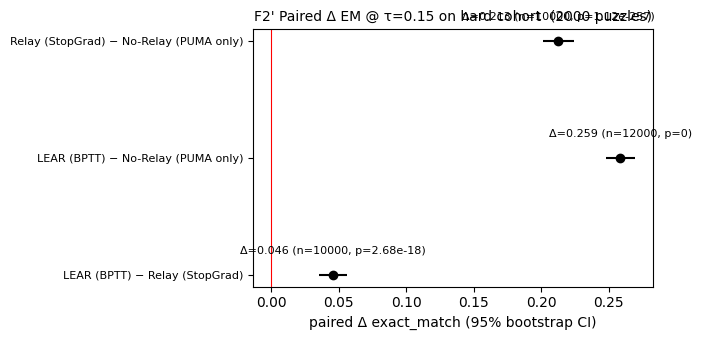

,A,B,n_pairs,mean_delta,ci_lo,ci_hi,p_paired_t
0,puma_loopholing_bptt,puma_loopholing_stop_grad,10000,0.0458,0.035100,0.055800,2.677262e-18
1,puma_loopholing_bptt,puma_no_loopholing,12000,0.2585,0.248167,0.269335,0.000000e+00
2,puma_loopholing_stop_grad,puma_no_loopholing,10000,0.2126,0.201100,0.224200,1.119765e-257


In [5]:
def paired_delta_em(df_in: pd.DataFrame, A: str, B: str, tau: float) -> pd.DataFrame:
    """Per-puzzle paired delta of exact_match for A vs B at a fixed tau.

    Returns one row per (puzzle_hash, embed_tying, seed).
    """
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)['exact_match']
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    out = out.rename(columns={A: f'em_{A}', B: f'em_{B}'})
    return out


def bootstrap_mean_ci(x: np.ndarray, n_boot: int = 2000, alpha: float = 0.05,
                     rng: np.random.Generator | None = None):
    rng = rng or np.random.default_rng(0)
    if len(x) == 0:
        return float('nan'), float('nan'), float('nan')
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = x[idx].mean()
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

TARGET_TAU = 0.15
rng = np.random.default_rng(0)

rows = []
for A, B in [
    ('puma_loopholing_bptt', 'puma_loopholing_stop_grad'),
    ('puma_loopholing_bptt', 'puma_no_loopholing'),
    ('puma_loopholing_stop_grad', 'puma_no_loopholing'),
]:
    pair = paired_delta_em(df_hard, A, B, TARGET_TAU)
    if pair.empty:
        rows.append({'A': A, 'B': B, 'n_pairs': 0,
                     'mean_delta': float('nan'), 'ci_lo': float('nan'), 'ci_hi': float('nan'),
                     'p_paired_t': float('nan')})
        continue
    deltas = pair['delta'].values.astype(float)
    m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000, rng=rng)
    from scipy import stats
    t_p = stats.ttest_1samp(deltas, 0.0).pvalue if len(deltas) > 1 else float('nan')
    rows.append({
        'A': A, 'B': B, 'n_pairs': len(deltas),
        'mean_delta': m, 'ci_lo': lo, 'ci_hi': hi,
        'p_paired_t': t_p,
    })

paired_summary = pd.DataFrame(rows)
print(f'Paired Δ EM at τ={TARGET_TAU} on hard cohort:')
print(paired_summary.round(4).to_string(index=False))

if not paired_summary.empty and paired_summary['n_pairs'].sum() > 0:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    yticks = []
    for i, r in paired_summary.iterrows():
        label = f"{OBJECTIVE_LABEL.get(r['A'], r['A'])} − {OBJECTIVE_LABEL.get(r['B'], r['B'])}"
        yticks.append(label)
        if pd.notna(r['mean_delta']):
            ax.errorbar(
                [r['mean_delta']], [i],
                xerr=[[r['mean_delta'] - r['ci_lo']], [r['ci_hi'] - r['mean_delta']]],
                fmt='o', color='black',
            )
            ax.text(r['mean_delta'], i + 0.18,
                    f"Δ={r['mean_delta']:.3f} (n={int(r['n_pairs'])}, p={r['p_paired_t']:.3g})",
                    fontsize=8, ha='center')
    ax.axvline(0, color='red', linewidth=0.8)
    ax.set_yticks(range(len(yticks)))
    ax.set_yticklabels(yticks, fontsize=8)
    ax.set_xlabel('paired Δ exact_match (95% bootstrap CI)')
    ax.set_title(
        f"F2' Paired Δ EM @ τ={TARGET_TAU} on hard cohort  ({n_puzzles_hard} puzzles)",
        fontsize=10,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F2p_paired_delta.png', dpi=180, bbox_inches='tight')
    plt.show()
paired_summary

## F4' — legality + late-step purity on the hard cohort

Same panels as F4 in the full notebook, restricted to the hard cohort. The
expectation is that the legality gap (BPTT vs StopGrad) widens on hard
puzzles — if it doesn't, the original ~3.4 pp legality advantage is just an
easy-puzzle effect.

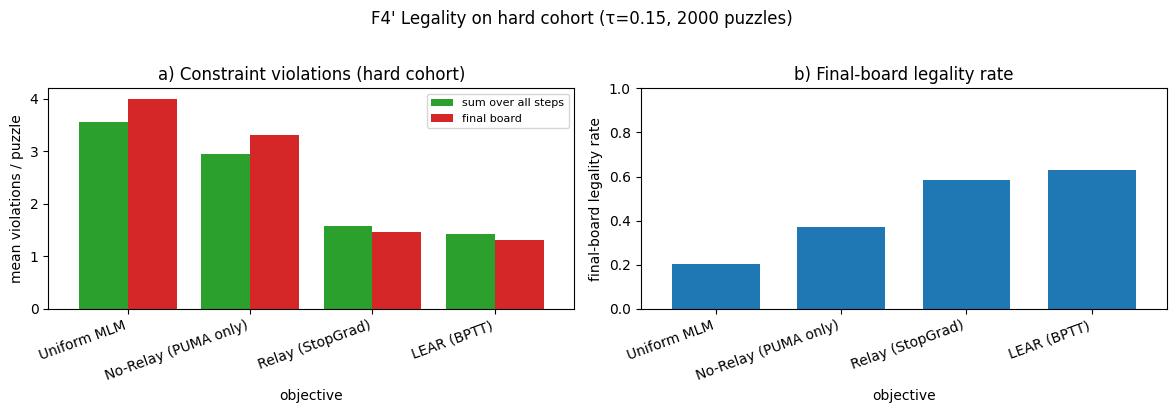

Mean violations:
                           violations_total_steps  final_violations
objective                                                          
mlm_uniform                                 3.548             3.997
puma_no_loopholing                          2.948             3.303
puma_loopholing_stop_grad                   1.572             1.464
puma_loopholing_bptt                        1.418             1.317

Final-board legality rate:
objective
mlm_uniform                  0.203
puma_no_loopholing           0.369
puma_loopholing_stop_grad    0.585
puma_loopholing_bptt         0.628
Name: _legal, dtype: float64


In [6]:
tau15 = df_hard[df_hard['tau'] == TARGET_TAU].copy()
if tau15.empty:
    print('No rows at tau =', TARGET_TAU)
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    legality = (
        tau15.groupby('objective', observed=True)
        [['violations_total_steps', 'final_violations']]
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    legality.plot(kind='bar', ax=axes[0], width=0.8,
                  color=['#2ca02c', '#d62728'])
    axes[0].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                            rotation=20, ha='right')
    axes[0].set_ylabel('mean violations / puzzle')
    axes[0].set_title("a) Constraint violations (hard cohort)")
    axes[0].legend(['sum over all steps', 'final board'], fontsize=8)

    # Final-board legality rate.
    leg_rate = (
        tau15.assign(_legal=tau15['final_violations'] == 0)
        .groupby('objective', observed=True)['_legal']
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    leg_rate.plot(kind='bar', ax=axes[1], width=0.7, color='#1f77b4')
    axes[1].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                            rotation=20, ha='right')
    axes[1].set_ylabel('final-board legality rate')
    axes[1].set_title('b) Final-board legality rate')
    axes[1].set_ylim(0, 1)
    fig.suptitle(
        f"F4' Legality on hard cohort (τ={TARGET_TAU}, {n_puzzles_hard} puzzles)",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F4p_legality_hard.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Mean violations:')
    print(legality.round(3))
    print('\nFinal-board legality rate:')
    print(leg_rate.round(3))

## F3' — solver alignment on hard puzzles, paired view

Per-puzzle paired Δ of `fill_order_spearman`. If LEAR's hypothesized
advantage is whole-trajectory credit assignment, the paired Δ vs StopGrad
should be cleanly positive on the hard cohort, *not* on the easy-tail.

In [7]:
def paired_delta_metric(df_in: pd.DataFrame, A: str, B: str, tau: float, metric: str) -> pd.DataFrame:
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)[metric]
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    return out

rows = []
for metric in ['fill_order_spearman', 'prefix_jaccard_at_5',
               'prefix_jaccard_at_10', 'prefix_jaccard_at_20']:
    for A, B in [
        ('puma_loopholing_bptt', 'puma_loopholing_stop_grad'),
        ('puma_loopholing_bptt', 'puma_no_loopholing'),
    ]:
        pair = paired_delta_metric(df_hard, A, B, TARGET_TAU, metric)
        if pair.empty:
            continue
        deltas = pair['delta'].dropna().values.astype(float)
        if len(deltas) < 2:
            continue
        m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000,
                                       rng=np.random.default_rng(0))
        rows.append({'metric': metric,
                     'pair': f"{OBJECTIVE_LABEL[A]} − {OBJECTIVE_LABEL[B]}",
                     'n_pairs': int(len(deltas)),
                     'mean': m, 'ci_lo': lo, 'ci_hi': hi})
align_summary = pd.DataFrame(rows)
if not align_summary.empty:
    print("F3' paired-Δ alignment metrics (hard cohort, τ={:.2f}):".format(TARGET_TAU))
    print(align_summary.round(4).to_string(index=False))
else:
    print('No alignment data available.')

F3' paired-Δ alignment metrics (hard cohort, τ=0.15):
              metric                               pair  n_pairs   mean  ci_lo  ci_hi
 fill_order_spearman     LEAR (BPTT) − Relay (StopGrad)     7330 0.0088 0.0067 0.0107
 fill_order_spearman LEAR (BPTT) − No-Relay (PUMA only)     8796 0.0312 0.0291 0.0334
 prefix_jaccard_at_5     LEAR (BPTT) − Relay (StopGrad)    10000 0.0137 0.0098 0.0177
 prefix_jaccard_at_5 LEAR (BPTT) − No-Relay (PUMA only)    12000 0.0918 0.0844 0.0992
prefix_jaccard_at_10     LEAR (BPTT) − Relay (StopGrad)    10000 0.0052 0.0024 0.0080
prefix_jaccard_at_10 LEAR (BPTT) − No-Relay (PUMA only)    12000 0.2439 0.2384 0.2494
prefix_jaccard_at_20     LEAR (BPTT) − Relay (StopGrad)    10000 0.0001 0.0000 0.0001
prefix_jaccard_at_20 LEAR (BPTT) − No-Relay (PUMA only)    12000 0.0223 0.0207 0.0241


## Coverage-gated matched-NFE

Same as the matched-NFE cell in the full notebook, but flagged: don't trust
any (model, tying, B) cell with coverage < 0.6 of the hard cohort — those
rows are interpolation-bias-dominated.

In [8]:
def matched_nfe(df_in: pd.DataFrame, metric_col: str, B: float, eps: float = 1.5) -> pd.DataFrame:
    rows = []
    for (obj, tying), sub in df_in.groupby(['objective', 'embed_tying'], observed=True):
        for ph, g in sub.groupby('puzzle_hash'):
            if g[metric_col].isna().all():
                continue
            xs = g['rollout_steps'].astype(float).values
            ys = g[metric_col].astype(float).values
            order = np.argsort(xs)
            xs = xs[order]; ys = ys[order]
            if not ((xs.min() - eps) <= B <= (xs.max() + eps)):
                continue
            rows.append({'objective': obj, 'embed_tying': tying,
                         'puzzle_hash': ph, metric_col: float(np.interp(B, xs, ys))})
    return pd.DataFrame(rows)

nfe_obs = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)['rollout_steps']
    .mean()
)
B_grid = np.linspace(float(nfe_obs.min()), float(nfe_obs.max()), 5).round(1).tolist()
print('B grid:', B_grid)
for B in B_grid:
    em = matched_nfe(df_hard, 'exact_match', B)
    if em.empty:
        continue
    summary = (em.groupby(['objective', 'embed_tying'], observed=True)['exact_match']
               .agg(['mean', 'count'])
               .rename(columns={'mean': f'em@NFE={B}', 'count': f'n@NFE={B}'}))
    coverage = summary[f'n@NFE={B}'] / n_puzzles_hard
    print(f'\n=== matched NFE = {B} ({n_puzzles_hard} hard puzzles total) ===')
    print(summary.unstack('embed_tying'))
    print('coverage:')
    print(coverage.unstack('embed_tying').round(2))
    if (coverage < 0.6).any():
        print('** WARNING: at least one (objective, tying) has coverage < 0.6; **'
              ' the matched-NFE EM at this B is selection-biased toward late-failing puzzles.')

B grid: [6.0, 9.9, 13.8, 17.7, 21.6]

=== matched NFE = 6.0 (2000 hard puzzles total) ===
                          em@NFE=6.0           n@NFE=6.0       
embed_tying                     tied    untied      tied untied
objective                                                      
mlm_uniform                 0.185046  0.174515      1197   1083
puma_loopholing_bptt        0.514286  0.487151      1820   1829
puma_loopholing_stop_grad   0.514529  0.500136      1778   1837
puma_no_loopholing          0.307440  0.345757      1371   1194
coverage:
embed_tying                tied  untied
objective                              
mlm_uniform                0.60    0.54
puma_loopholing_bptt       0.91    0.91
puma_loopholing_stop_grad  0.89    0.92
puma_no_loopholing         0.69    0.60
** WARNING: at least one (objective, tying) has coverage < 0.6; ** the matched-NFE EM at this B is selection-biased toward late-failing puzzles.

=== matched NFE = 9.9 (2000 hard puzzles total) ===
              

## Per-stratum table

Three strata of the hard cohort that probe different things:

1. **Heuristic-Advanced** (Advanced tier, no Brute Force in strategies):
   solver finished by deduction with naked/hidden pairs/triples/quads. Pure
   strategy-reasoning probe.
2. **Heuristic-Master** (Master tier; X-Wings, Swordfish, Forcing Chains):
   harder still, deduction-only.
3. **BF-rating-tail** (BruteForce tier with rating in the top ½ of the
   hard-cohort BF rating distribution): brute-force-needed puzzles where the
   solver's lookahead was deepest.

These strata are tiny (BF-rating-tail tends to dominate by raw count) but
they're where the BPTT-vs-StopGrad story would have to land.

In [9]:
def _has_bf(strats):
    if strats is None:
        return False
    try:
        return 'Brute Force' in list(strats)
    except TypeError:
        return False

df_hard['_has_bf'] = df_hard['strategies_used'].apply(_has_bf)
is_adv = (df_hard['hardest_strategy'] == 'Advanced') & (~df_hard['_has_bf'])
is_master = (df_hard['hardest_strategy'] == 'Master') & (~df_hard['_has_bf'])
is_bf = df_hard['hardest_strategy'] == 'BruteForce'
rating_med_bf = df_hard.loc[is_bf, 'rating'].median()
is_bf_tail = is_bf & (df_hard['rating'] >= rating_med_bf)

strata = {
    'heuristic-Advanced': is_adv,
    'heuristic-Master': is_master,
    'BF-rating-tail (rating>=' + f'{rating_med_bf:.0f}': is_bf_tail,
}
rows = []
for name, mask in strata.items():
    sub = df_hard[mask & (df_hard['tau'] == TARGET_TAU)]
    if sub.empty:
        rows.append({'stratum': name, 'n_puzzles': 0})
        continue
    em = (sub.groupby('objective', observed=True)['exact_match']
          .mean()
          .reindex(OBJECTIVE_ORDER))
    rows.append({
        'stratum': name,
        'n_puzzles': sub['puzzle_hash'].nunique(),
        **{f'EM:{OBJECTIVE_LABEL[o]}': float(em.get(o, np.nan)) for o in OBJECTIVE_ORDER},
    })
stratum_summary = pd.DataFrame(rows)
print(f'Per-stratum exact match @ τ={TARGET_TAU} (hard cohort):')
print(stratum_summary.round(3).to_string(index=False))

Per-stratum exact match @ τ=0.15 (hard cohort):
                   stratum  n_puzzles  EM:Uniform MLM  EM:No-Relay (PUMA only)  EM:Relay (StopGrad)  EM:LEAR (BPTT)
        heuristic-Advanced        107           0.351                    0.472                0.647           0.706
          heuristic-Master          6           0.200                    0.556                0.500           0.694
BF-rating-tail (rating>=23        883           0.120                    0.301                0.547           0.586
